In [ ]:
import cv2
from ultralytics import YOLO
import time

print("Initializing AI Vision Engine...")

model = YOLO('yolov8n.pt') 
video_path = "traffic.mp4" 
cap = cv2.VideoCapture(video_path)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))
output_path = "annotated_traffic.mp4"
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"Processing video: {width}x{height} at {fps} FPS...")
start_time = time.time()


frame_count = 0

while cap.isOpened():
    success, frame = cap.read()
    
    if success:
        
        results = model.track(frame, persist=True, verbose=False)
        
        
        annotated_frame = results[0].plot()
        
        
        out.write(annotated_frame)
        
        frame_count += 1
        if frame_count % 30 == 0:
            print(f"Processed {frame_count} frames...")
            
    else:
        
        break


cap.release()
out.release()
cv2.destroyAllWindows()

end_time = time.time()
print(f"✅ Video processing complete! Saved as '{output_path}'")
print(f"Total processing time: {round(end_time - start_time, 2)} seconds")

Initializing AI Vision Engine...
Processing video: 1920x1080 at 29 FPS...
Processed 30 frames...
Processed 60 frames...
Processed 90 frames...
Processed 120 frames...
Processed 150 frames...
Processed 180 frames...
Processed 210 frames...
Processed 240 frames...
Processed 270 frames...
Processed 300 frames...
Processed 330 frames...
Processed 360 frames...
Processed 390 frames...
Processed 420 frames...
Processed 450 frames...
Processed 480 frames...
Processed 510 frames...
Processed 540 frames...
Processed 570 frames...
Processed 600 frames...
Processed 630 frames...
Processed 660 frames...
Processed 690 frames...
✅ Video processing complete! Saved as 'annotated_traffic.mp4'
Total processing time: 270.42 seconds


In [ ]:
import cv2
from ultralytics import YOLO
import pandas as pd
import time

print("Initializing AI Data Extraction Engine...")


model = YOLO('yolov8n.pt') 
video_path = "traffic.mp4" 
cap = cv2.VideoCapture(video_path)
traffic_data = []
frame_count = 0

print("Scanning frames and extracting object data...")


while cap.isOpened():
    success, frame = cap.read()
    if not success:
        break 
        
    
    results = model.track(frame, persist=True, verbose=False)
    
    
    if results[0].boxes.id is not None: 
        boxes = results[0].boxes.xyxy.cpu().numpy() 
        track_ids = results[0].boxes.id.cpu().numpy() 
        classes = results[0].boxes.cls.cpu().numpy() 
        confidences = results[0].boxes.conf.cpu().numpy() 
        
        
        for box, track_id, cls, conf in zip(boxes, track_ids, classes, confidences):
            traffic_data.append({
                'Frame': frame_count,
                'Object_ID': int(track_id),
                'Class_ID': int(cls),
                'Class_Name': model.names[int(cls)], 
                'Confidence_Score': round(float(conf), 2),
                'X_Center': (box[0] + box[2]) / 2, 
                'Y_Center': (box[1] + box[3]) / 2
            })
            
    frame_count += 1

cap.release()


df_traffic = pd.DataFrame(traffic_data)
df_traffic.to_csv("traffic_data.csv", index=False)

print(f"✅ Successfully converted video into data!")
print(f"Extracted {len(df_traffic)} data points and saved to 'traffic_data.csv'")
print("\nPreview of the structured data:")
print(df_traffic.head())

Initializing AI Data Extraction Engine...
Scanning frames and extracting object data...
✅ Successfully converted video into data!
Extracted 6623 data points and saved to 'traffic_data.csv'

Preview of the structured data:
   Frame  Object_ID  Class_ID Class_Name  Confidence_Score     X_Center  \
0      0          1         7      truck              0.43  1318.104126   
1      0          2         2        car              0.27  1216.206299   
2      0          3         2        car              0.27  1318.909180   
3      0          4         5        bus              0.25  1216.442627   
4      1          1         7      truck              0.31  1327.219238   

     Y_Center  
0  108.116165  
1  600.816895  
2  109.382980  
3  600.118408  
4  113.495476  


📊 Traffic Volume Breakdown:
Object Type  Total Count
        car           60
      truck           23
        bus            7
     person            7
      train            6


C:\Users\cashgen\AppData\Local\Temp\ipykernel_19344\4049505519.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


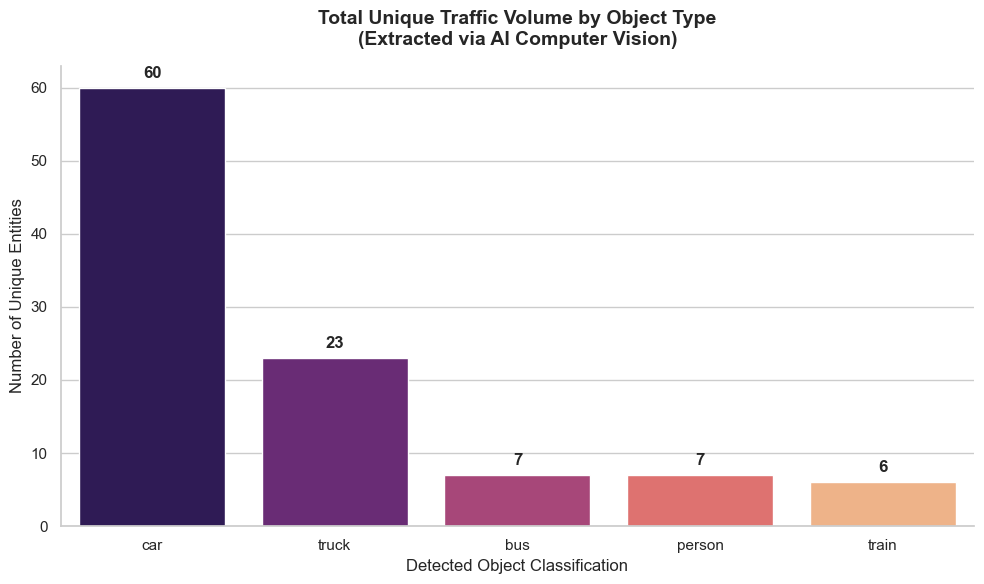

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("traffic_data.csv")


unique_objects = df.drop_duplicates(subset=['Object_ID', 'Class_Name'])


traffic_volume = unique_objects['Class_Name'].value_counts().reset_index()
traffic_volume.columns = ['Object Type', 'Total Count']

print("📊 Traffic Volume Breakdown:")
print(traffic_volume.to_string(index=False))


plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x='Object Type', 
    y='Total Count', 
    data=traffic_volume, 
    palette='magma'
)

plt.title("Total Unique Traffic Volume by Object Type\n(Extracted via AI Computer Vision)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Detected Object Classification", fontsize=12)
plt.ylabel("Number of Unique Entities", fontsize=12)


for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', 
                xytext=(0, 5), textcoords='offset points',
                fontsize=12, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()